In [ ]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


In [ ]:
# Step 3: Load Dataset
matches = pd.read_csv('matches.csv')

In [ ]:
# Display first 5 rows
print(matches.head())


       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [ ]:
# Step 4: Dataset Information
print(matches.info())
print(matches.describe())
print(matches.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

# Task 1: Matches Won Per **Team**

In [ ]:
team_matches = matches['winner'].value_counts()

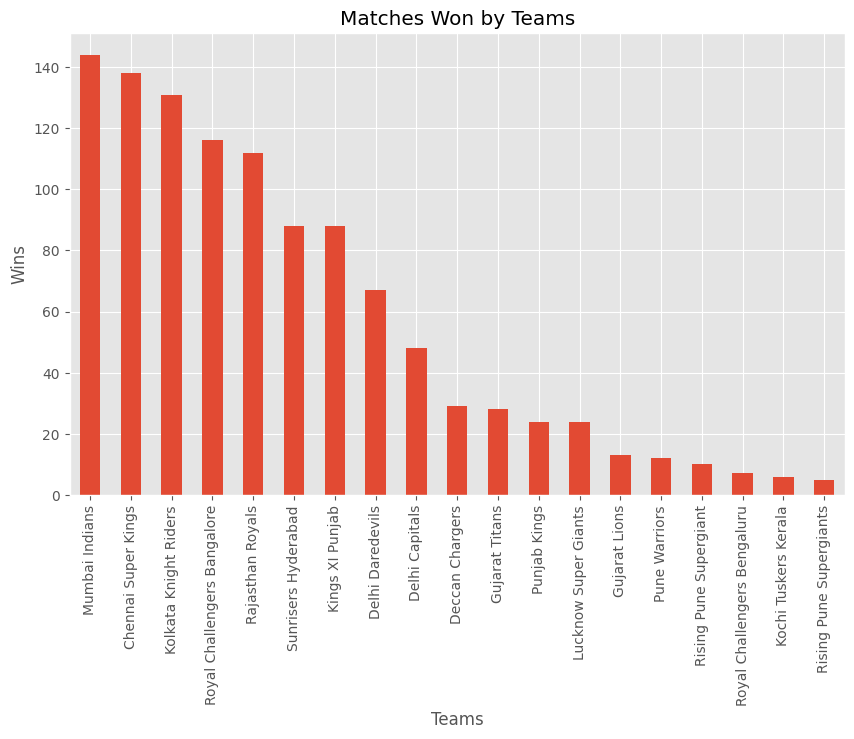

In [ ]:
plt.figure(figsize=(10,6))
team_matches.plot(kind='bar')
plt.title("Matches Won by Teams")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.show()


# Task 2: Most Successful **Team**

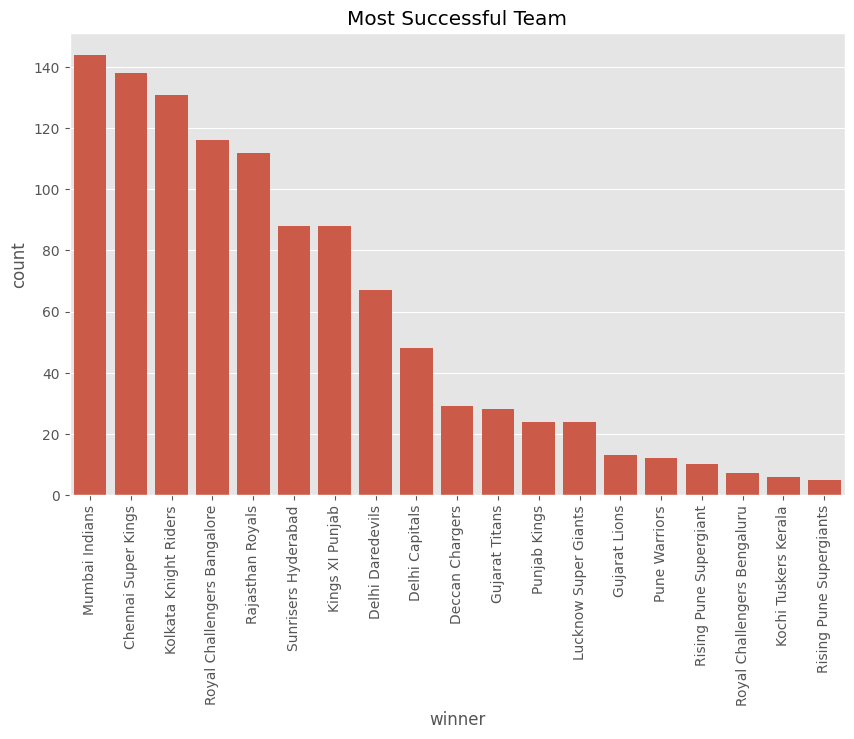

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='winner',
    data=matches,
    order=matches['winner'].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Most Successful Team")
plt.show()



# Task 3: Toss Decision Analysis


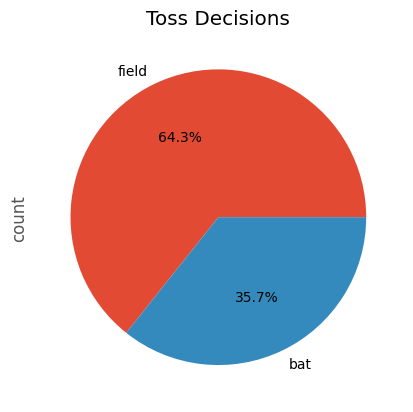

In [ ]:
matches['toss_decision'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Toss Decisions")
plt.show()



# Task 4: Top Player of **Match**

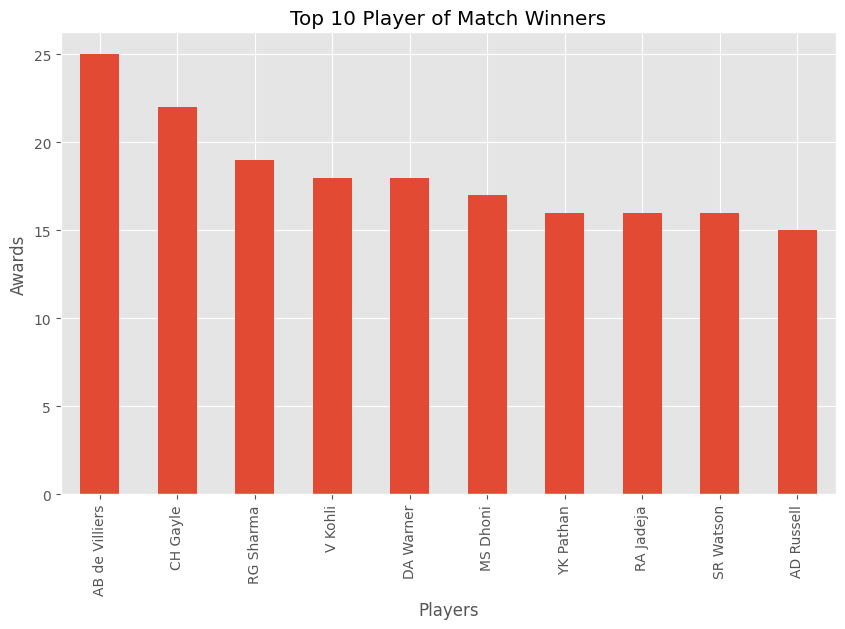

In [ ]:
top_players = matches['player_of_match'] \
    .value_counts().head(10)

plt.figure(figsize=(10,6))
top_players.plot(kind='bar')
plt.title("Top 10 Player of Match Winners")
plt.xlabel("Players")
plt.ylabel("Awards")
plt.show()


# Task 5: Venue **Analysis**

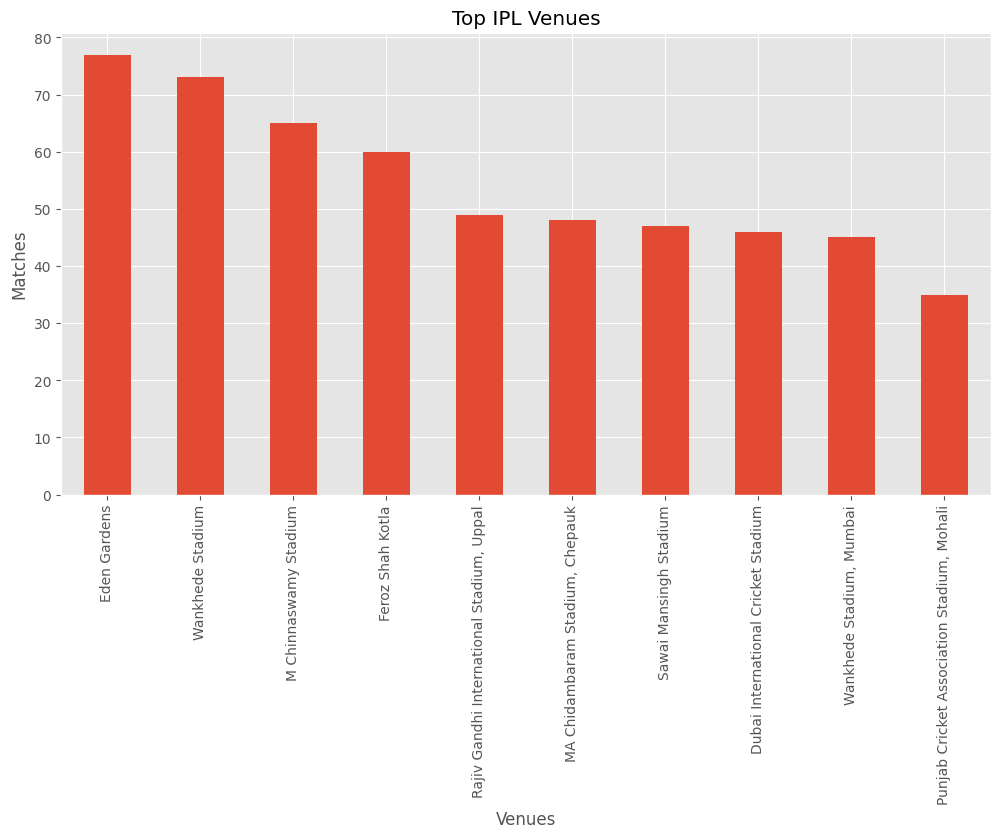

In [ ]:
venue_matches = matches['venue'].value_counts().head(10)

plt.figure(figsize=(12,6))
venue_matches.plot(kind='bar')
plt.title("Top IPL Venues")
plt.xlabel("Venues")
plt.ylabel("Matches")
plt.show()



# Task 6: Team Performance Dashboard


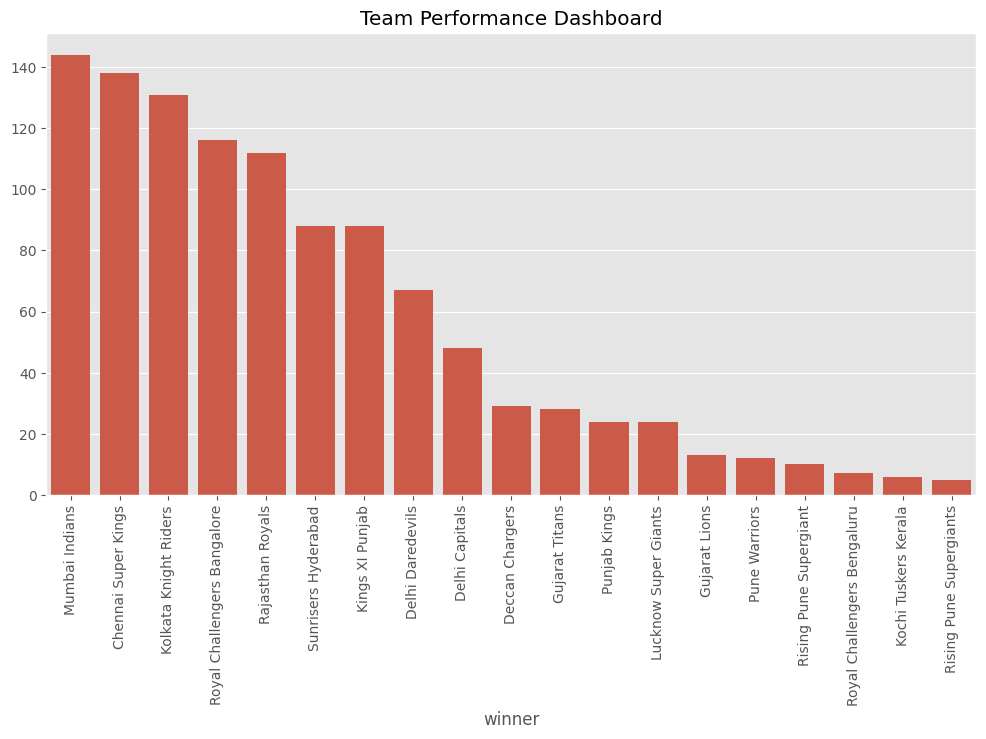

In [ ]:
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=team_wins.index,
    y=team_wins.values
)

plt.xticks(rotation=90)
plt.title("Team Performance Dashboard")
plt.show()

# Task 7: Winning Percentage


winner
Mumbai Indians                 13.150685
Chennai Super Kings            12.602740
Kolkata Knight Riders          11.963470
Royal Challengers Bangalore    10.593607
Rajasthan Royals               10.228311
Sunrisers Hyderabad             8.036530
Kings XI Punjab                 8.036530
Delhi Daredevils                6.118721
Delhi Capitals                  4.383562
Deccan Chargers                 2.648402
Name: count, dtype: float64


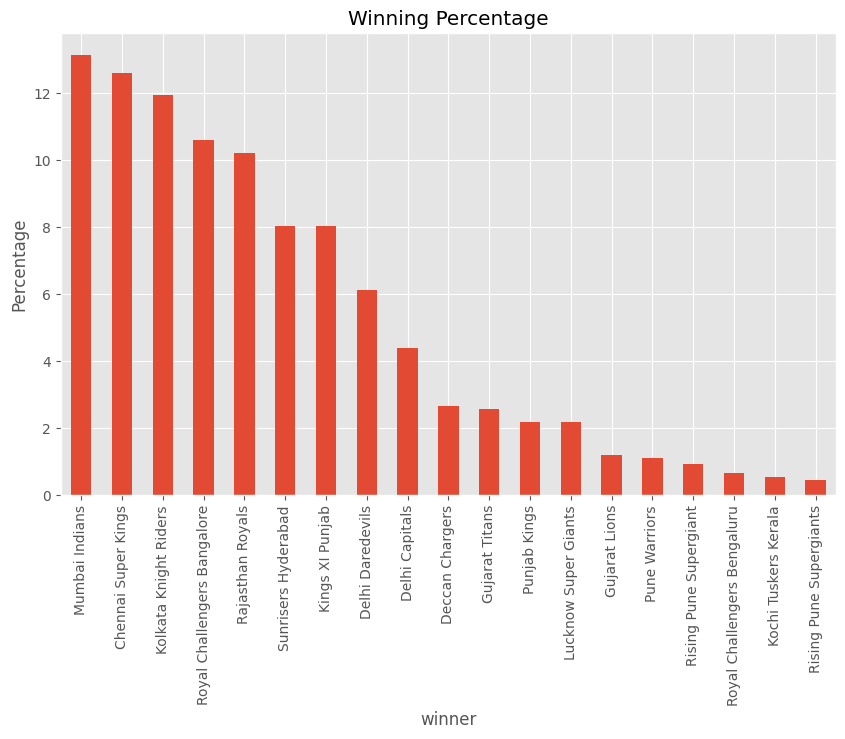

In [ ]:
total_matches = matches.shape[0]

wins = matches['winner'].value_counts()

win_percentage = (wins / total_matches) * 100

print(win_percentage.head(10))

plt.figure(figsize=(10,6))
win_percentage.plot(kind='bar')

plt.title("Winning Percentage")
plt.ylabel("Percentage")
plt.show()


# Task 8: Full Dashboard (2x2 Grid)

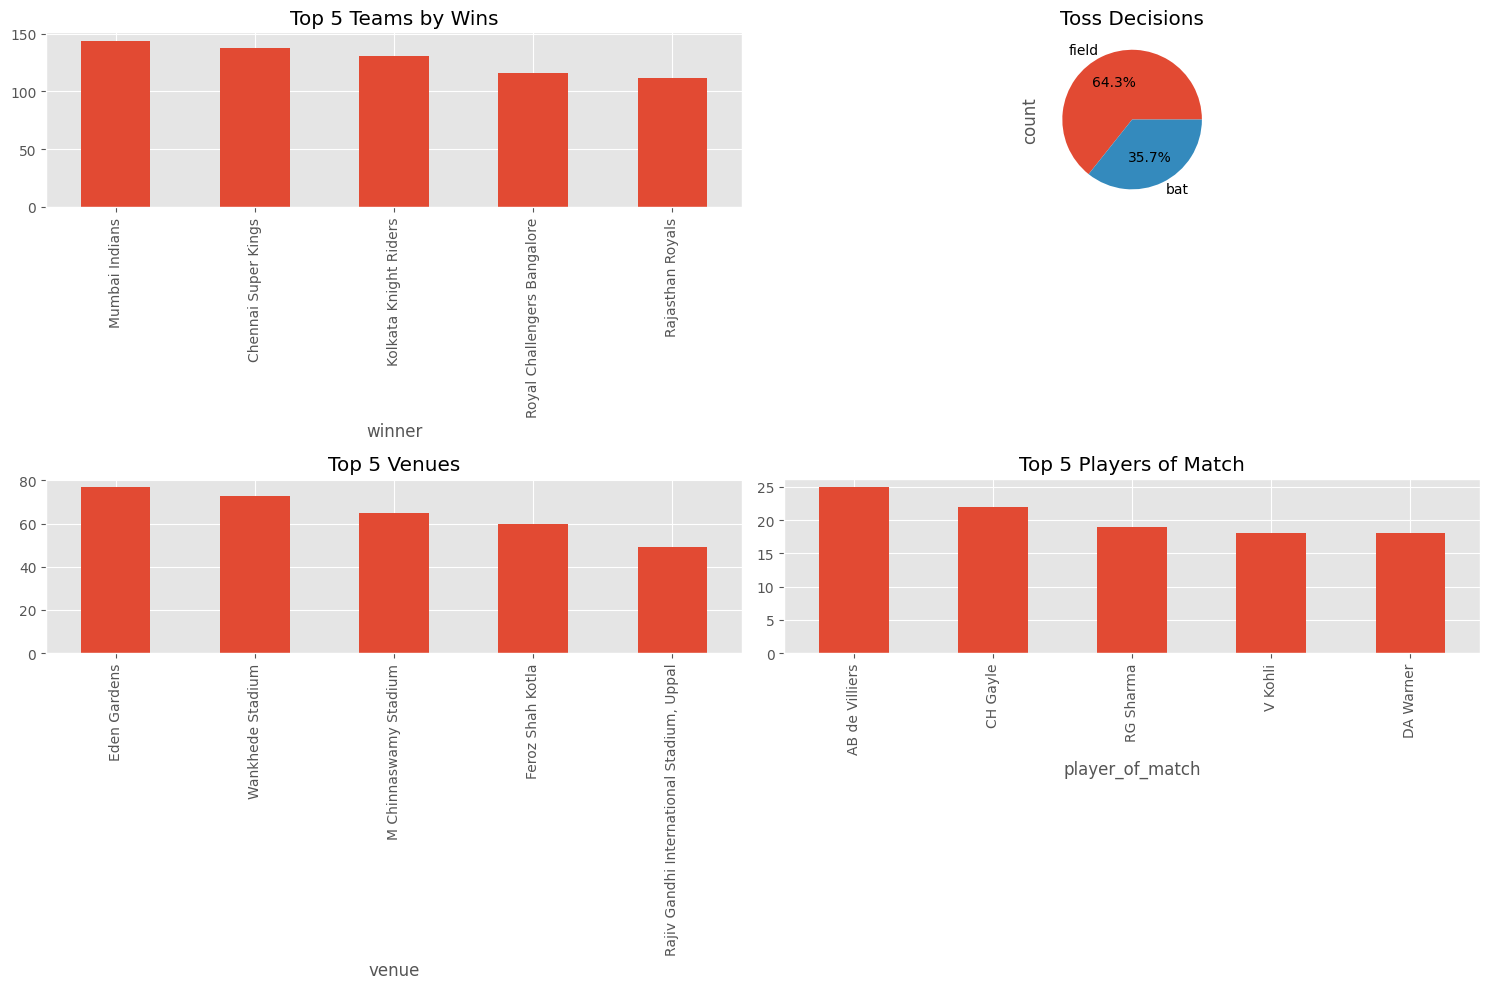

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))

matches['winner'].value_counts().head(5).plot(
    kind='bar',
    ax=ax[0,0],
    title="Top 5 Teams by Wins"
)

matches['toss_decision'].value_counts().plot(
    kind='pie',
    ax=ax[0,1],
    autopct='%1.1f%%',
    title="Toss Decisions"
)

matches['venue'].value_counts().head(5).plot(
    kind='bar',
    ax=ax[1,0],
    title="Top 5 Venues"
)

matches['player_of_match'].value_counts().head(5).plot(
    kind='bar',
    ax=ax[1,1],
    title="Top 5 Players of Match"
)

plt.tight_layout()
plt.show()